# Gene Centric indexer
The goal:
```
gene{}
     |___ case[]
             |___ ssm[]
                   |___ consequence[]
                   |             |_____ transcript{}
                   |                          |_____ annotation{}
                   |___ observation[]
```

In [148]:
import os
import requests
import uuid
%load_ext autoreload
from exports.mappings import GeneMapper, SSMMapper, Mapper
from exports.utils import get_array_paths

from pyspark.sql.functions import col, explode, collect_list, size, sum, first, struct, udf, regexp_extract, lit, count, broadcast
from pyspark.sql.types import StringType

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load combined maf into spark

In [149]:
url = 's3a://test/small_combined_mafs.csv'
    
df = sqlContext.read.format('com.databricks.spark.csv')\
                .options(header='true', inferschema='true')\
                .load(url)\
                .drop_duplicates()
        

In [150]:
df.count()

18710

## Rename and select desired columns from the maf file

In [151]:
%autoreload
from exports.utils import (
    maf_annotation_map,
    maf_gene_map,
    maf_observation_map,
    maf_ssm_map,
    maf_transcript_map,
    normal_genotype_map,
    tumor_genotype_map,
    tumor_validation_map,
    read_depth_map,
    input_bam_map,
    sample_map,
    maf_cols
)

maf_df = df.select(*( col(v).alias(k) for k,v in maf_cols.items() ))

## Augment maf df by extracting submitter_id and creating ssm_uuids

In [152]:
# TODO: Map the sample UUIDs to case UUIDs without relying on the barcode
maf_df = maf_df.withColumn('_case_submitter_id',
                           regexp_extract(col('tumor_sample_barcode'),
                                          '([A-Z]{4}-[A-Z0-9]{2}-[A-Z0-9]{4})',1))
maf_ssm_map.update({'_case_submitter_id':'_case_submitter_id'})

In [153]:
# TODO: Support different mutation types
def ssm_uuid(chromosome, start_position, ref_allele, tumor_allele):
    '''
    SNP: "{chromosome}:g.{start_position}{reference_allele}>{tumor_allele}"
    DEL: "{chromosome}:g.{start_position}del{reference_allele}"
    INS: "{chromosome}:g.{start_position}_{end_position}ins{tumor_allele}"
    '''
    chromosome = chromosome.replace('chr','')
    label = '{}:g.{}:{}>{}'.format(chromosome, start_position, ref_allele, tumor_allele)
    return str(uuid.uuid5(uuid.UUID('d15296a3-38ed-412e-8ace-75e235f82f55'), label))

ssm_uuid_udf =udf(ssm_uuid, StringType())
maf_df = maf_df.withColumn('ssm_uuid', ssm_uuid_udf(col('chromosome'), col('start_position'), col('reference_allele'), col('tumor_allele')))
maf_observation_map.update({'ssm_uuid':'ssm_uuid'})
maf_ssm_map.update({'ssm_uuid':'ssm_uuid'})

## Construct the base dfs out of the maf df by selecting the columns we want

### Gene df

In [154]:
gene_df = maf_df.select(*( col(k) for k in maf_gene_map.keys() + ['_case_submitter_id'] ))
# Fill in empty data we don't know about
gene_df = gene_df.withColumn('description', lit(None).cast(StringType()))\
                 .drop_duplicates()

In [155]:
#gene_df.persist().count()

### SSM df

In [156]:
ssm_df = maf_df.select(*( col(k) for k in maf_ssm_map.keys() ))\
               .drop_duplicates()
#ssm_df.printSchema()

### Transcript-annotation df

```
transcript{}
     |_____ annotation{}
```

In [157]:
# Rename columns
tran_anno_df = maf_df.select(*( maf_transcript_map.keys() + maf_annotation_map.keys() ))
# Select annotation into nested format
tran_anno_df = tran_anno_df.select(struct(*maf_annotation_map.keys()).alias('annotation'), *maf_transcript_map.keys())\
                           .drop_duplicates()
#tran_anno_df.printSchema()

In [158]:
#tran_anno_df.count()

### Observation df

In [159]:
observation_df = maf_df.select(*(maf_observation_map.keys()
                                 +normal_genotype_map.keys()
                                 +tumor_genotype_map.keys()
                                 +tumor_validation_map.keys()
                                 +read_depth_map.keys()
                                 +input_bam_map.keys()
                                 +sample_map.keys()))

# observation has a bunch of internal docs
observation_df = observation_df.select(struct(*normal_genotype_map.keys()).alias('normal_genotype'),
                                       struct(*tumor_genotype_map.keys()).alias('tumor_genotype'),
                                       struct(*tumor_validation_map.keys()).alias('validation'),
                                       struct(*read_depth_map.keys()).alias('read_depth'),
                                       struct(*input_bam_map.keys()).alias('input_bam_file'),
                                       struct(*sample_map.keys()).alias('sample'),
                                       *maf_observation_map.keys())\
                                .drop('ssm_uuid')\
                                .drop_duplicates()

In [160]:
#observation_df.count()

### Get case dataframe from existing graph

elasticsearch-hadoop has a bug where we can't load nested docs

See elasticsearch-hadoop#856
```python
doc = requests.get('http://elasticsearchvis.service.consul:9200/gdc_from_graph/case/_search',
                   auth=(os.environ.get("GDC_ES_USER"),
                         os.environ.get("GDC_ES_PASS"))
                  ).json()['hits']['hits'][0]['_source']

docs = [ r['_source'] for r in requests.get('http://elasticsearch.service.consul:9200/gdc_from_graph/case/_search?size=1',
                  ).json()['hits']['hits']]

paths = [ get_array_paths(d) for d in docs ]
paths = reduce(set.union, map(set, paths))
```

In [161]:
case_df = sqlContext.read.format("es")\
    .option('es.nodes', 'elasticsearch.service.consul')\
    .option('es.read.field.include', 'case_id,submitter_id,project_id')\
    .option('es.resource.read', 'gdc_from_graph/case')\
    .option('es.nodes.resolve.hostname','false')\
    .load("gdc_from_graph")

In [162]:
#case_df = case_df.limit(10)

## Assemble constituent parts

Remember what we're shooting for:
```
gene{}
     |___ case[]
             |___ ssm[]
                   |___ consequence[]
                   |             |_____ transcript{}
                   |                          |_____ annotation{}
                   |___ observation[]
```

### Merge annotation with transcript

In [163]:
cons_tran_anno_df = tran_anno_df.select(struct(struct(*tran_anno_df.columns).alias('transcript')).alias('consequence'), 'gene_symbol')\
                                .groupBy('gene_symbol')\
                                .agg(collect_list('consequence').alias('consequence'))
                                #.drop('gene_symbol')

In [164]:
#cons_tran_anno_df.count()

## Utils for salting

In [165]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [166]:
# For evaluating basic join key salts
def view_salt(pdf1, pdf2):
    f, axes = plt.subplots(1,2, figsize=(10,4), sharex=False)
    pdf1.columns = ['salt_key', 'count']
    pdf2.columns = ['salt_key', 'count']
    axes[0].plot(pdf1['count'], 'b.')
    axes[0].set_yscale('log')
    axes[0].set_ylim(10)
    axes[0].set_xlim(0,len(pdf1))
    axes[0].set_title('unsalted')
    axes[1].plot(pdf2['count'], 'g.')
    axes[1].set_xlim(0,len(pdf2))
    axes[1].set_title('salted')
    plt.show()

In [167]:
# Evaluates salting by contained doc counts
def view_salt2(df):
    f, axes = plt.subplots(1,2, figsize=(10,4), sharex=False)
    pdf1 = df.groupBy('salt_key').agg(sum('doc_count').alias('sum')).toPandas()
    pdf1.sort_values('sum', ascending=False).reset_index(drop=True).plot(ax=axes[0])
    axes[0].set_yscale('log')
    axes[0].set_title('unsalted')
    
    pdf2 = df.groupBy('salt_key').agg(sum('doc_count').alias('sum')).toPandas()
    pdf2.sort_values('sum', ascending=False).reset_index(drop=True).plot(ax=axes[1])
    axes[1].set_yscale('log')
    axes[1].set_title('salted')

In [168]:
import random
def salt(key, doc_count=0):
    return str(random.randint(0,int(max(0,doc_count-4)*4)))+key
salt_udf = udf(salt, StringType())

### Join observation with consequence

In [169]:
salted_observation_df = observation_df.withColumn('salt_key', salt_udf(col('gene_symbol')))\
                                      .repartition(1024, 'salt_key')
salted_observation_df.persist().count()

18710

In [170]:
salted_consequence_df = cons_tran_anno_df.withColumn('salt_key', salt_udf(col('gene_symbol')))\
                                         .repartition(64, 'salt_key')
salted_consequence_df.persist().count()

10656

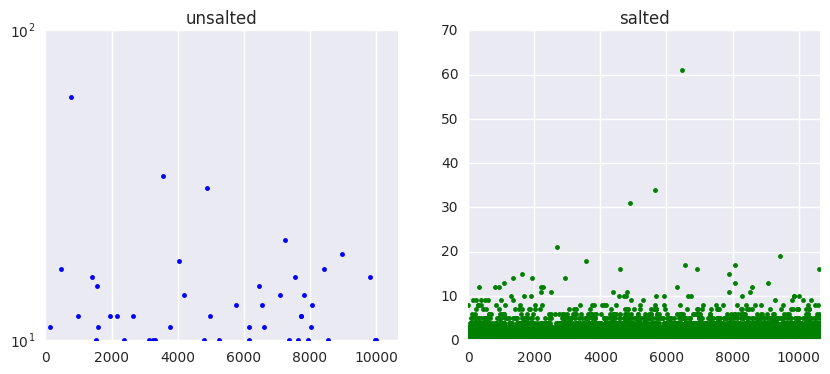

In [171]:
# Partitions before and after salting
pdf1 = salted_observation_df.groupBy('gene_symbol').agg(count('gene_symbol')).toPandas()
pdf2 = salted_observation_df.groupBy('salt_key').agg(count('gene_symbol')).toPandas()
view_salt(pdf1, pdf2)

In [172]:
cons_obs = salted_consequence_df.join(salted_observation_df, salted_consequence_df.gene_symbol == salted_observation_df.gene_symbol, 'outer')\
                            .drop(salted_consequence_df.gene_symbol)\
                            .drop(salted_consequence_df.salt_key)\
                            .select('gene_symbol','consequence',struct(*[c for c in salted_observation_df.columns if c != 'gene_symbol']).alias('observation'))                   

In [173]:
#pdf = cons_obs.groupBy('gene_symbol').agg(count('gene_symbol')).toPandas()

### Join consequence into ssm

In [174]:
pdf = cons_obs.select('gene_symbol', size('consequence')).toPandas()

In [175]:
pdf.max()

gene_symbol          hsa-mir-1253
size(consequence)              59
dtype: object

In [176]:
# Salt consequence-observation
salted_cons_obs = cons_obs.withColumn('doc_count', size(col('consequence')))\
                            .withColumn('salt_key', salt_udf(col('gene_symbol'), col('doc_count')))
#salted_cons_obs.repartition(1024, 'salt_key').count()

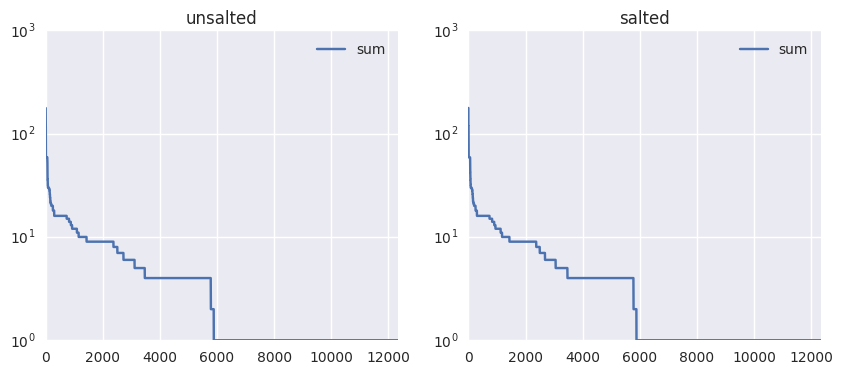

In [177]:
view_salt2(salted_cons_obs)

In [178]:
salted_ssm = ssm_df.withColumn('salt_key', salt_udf(col('gene_symbol')))
salted_ssm.repartition('salt_key').persist().count()

18430

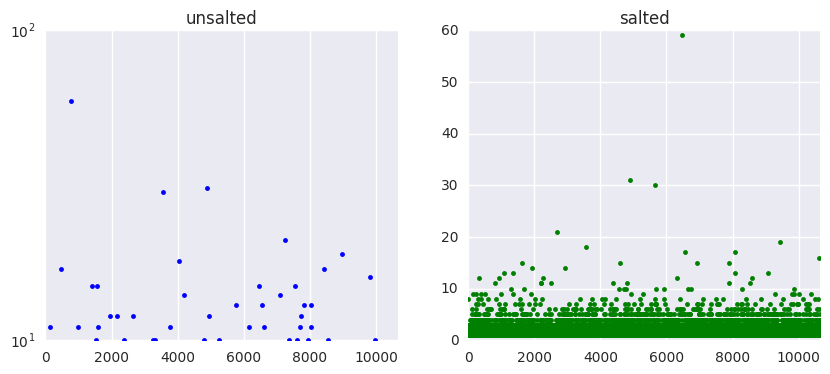

In [179]:
# Partitions before and after salting
pdf1 = salted_ssm.groupBy('gene_symbol').agg(count('gene_symbol')).toPandas()
pdf2 = salted_ssm.groupBy('salt_key').agg(count('gene_symbol')).toPandas()
view_salt(pdf1, pdf2)

In [180]:
sqlContext.sql("set spark.sql.shuffle.partitions=2048")

DataFrame[key: string, value: string]

In [181]:
salted_ssm.persist().count()

18430

In [182]:
ssm_cons = salted_cons_obs.repartition(2048,'salt_key').join(salted_ssm, salted_ssm.gene_symbol == salted_cons_obs.gene_symbol, 'left')\
                        .drop(salted_cons_obs.gene_symbol)\
                        .drop(salted_cons_obs.salt_key)\
                        .select('_case_submitter_id', struct('consequence','observation',*ssm_df.columns).alias('ssm'))\
                        .groupBy('_case_submitter_id')\
                        .agg(collect_list('ssm').alias('ssm'))

In [183]:
%%time
ssm_cons.persist().count()

CPU times: user 291 ms, sys: 105 ms, total: 396 ms
Wall time: 5.31 s


3906

### Join ssm with case

In [184]:
case_ssm = case_df.join(ssm_cons, case_df.submitter_id == ssm_cons._case_submitter_id, 'left')\
                    .drop(ssm_cons._case_submitter_id)\
                    .select('submitter_id', struct('ssm', *case_df.columns).alias('case'))

### Join case with gene

In [185]:
gene_centric = gene_df.join(case_ssm, gene_df._case_submitter_id == case_ssm.submitter_id, 'inner')\
                    .groupBy(*gene_df.columns).agg(collect_list('case').alias('case'))

In [186]:
#gene_centric.explain()

In [187]:
gene_centric.printSchema()

root
 |-- gene_chromosome: string (nullable = true)
 |-- biotype: string (nullable = true)
 |-- gene_start: integer (nullable = true)
 |-- gene_end: integer (nullable = true)
 |-- canonical_transcript_id: string (nullable = true)
 |-- symbol: string (nullable = true)
 |-- gene_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- _case_submitter_id: string (nullable = true)
 |-- description: string (nullable = true)
 |-- case: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- ssm: array (nullable = true)
 |    |    |    |-- element: struct (containsNull = true)
 |    |    |    |    |-- consequence: array (nullable = true)
 |    |    |    |    |    |-- element: struct (containsNull = true)
 |    |    |    |    |    |    |-- transcript: struct (nullable = false)
 |    |    |    |    |    |    |    |-- annotation: struct (nullable = false)
 |    |    |    |    |    |    |    |    |-- existing_variation: string (nullable = true)
 |    | 

In [52]:
#gene_centric.cache()
gene_centric.persist().count()

17538

## Export df to es

#### Graph es index

In [53]:
print requests.get('http://elasticsearch.service.consul:9200/_cat/indices?v').text

health status index               pri rep docs.count docs.deleted store.size pri.store.size 
       close  gdc_from_graph_30                                                             
yellow open   gdc_legacy_graph_25  10   1   64215725            0     14.9gb         14.9gb 
yellow open   gdc_from_graph_34    10   1   38115517            0       13gb           13gb 
       close  gdc_legacy_graph_22                                                           
       close  gdc_from_graph_32                                                             
yellow open   gdc_from_graph_33    10   1   38115514            0       13gb           13gb 
yellow open   download_stats       10   1         96           21    971.3kb        971.3kb 
       close  gdc_legacy_graph_24                                                           
yellow open   gdc_legacy_graph_26  10   1   64215725            0     14.8gb         14.8gb 
yellow open   test_schema          10   1          6            0     

#### New vis index

In [54]:
print requests.get('http://elasticsearchvis.service.consul:9200/_cat/indices?v').text

health status index uuid                   pri rep docs.count docs.deleted store.size pri.store.size
green  open   test  r4e3eeRcT6Oogunyr1ljsg  10   0          0            0      1.2kb          1.2kb



In [55]:
print requests.get('http://elasticsearchvis.service.consul:9200/_cat/count/test?v').text

epoch      timestamp count
1479414685 20:31:25  0



In [56]:
print requests.delete('http://elasticsearchvis.service.consul:9200/gdc_from_graph').json()

{u'status': 404, u'error': {u'index_uuid': u'_na_', u'index': u'gdc_from_graph', u'resource.type': u'index_or_alias', u'root_cause': [{u'index_uuid': u'_na_', u'index': u'gdc_from_graph', u'resource.type': u'index_or_alias', u'resource.id': u'gdc_from_graph', u'reason': u'no such index', u'type': u'index_not_found_exception'}], u'reason': u'no such index', u'type': u'index_not_found_exception', u'resource.id': u'gdc_from_graph'}}


In [60]:
%autoreload
from exports.mappings import GeneMapper
m = GeneMapper()
m.mapping['properties']['case'].keys()
m.mapping['dynamic'] = 'true'
m.mapping['properties']['case']['dynamic'] = 'true'
m.mapping['properties']['case']['properties']['files']['dynamic'] = 'true'
m.mapping['properties']['case']['properties']['files']['properties']['cases']['dynamic'] = 'true'

In [ ]:
import json

print requests.delete('http://elasticsearchvis.service.consul:9200/test').json()

data = json.dumps({"settings":{"index":{
                "refresh_interval":"1s",
                "number_of_shards":20,
                "number_of_replicas":0,
                "mapper.dynamic":False,
                "mapping.nested_fields.limit":100,
                "mapping.total_fields.limit":2000
            }},"mappings":{
                "gene":m.mapping
            }})
print requests.put('http://elasticsearchvis.service.consul:9200/test', data=data).json()

{u'acknowledged': True}
{u'acknowledged': True, u'shards_acknowledged': True}


In [ ]:
%%time
gene_centric.write.format('org.elasticsearch.spark.sql')\
                    .option('es.nodes', 'elasticsearchvis.service.consul')\
                    .option('es.nodes.resolve.hostname','false')\
                    .option('es.resource.write', 'test/gene')\
                    .option('es.http.timeout', '10m')\
                    .option('es.batch.size.bytes','1mb')\
                    .save('test/gene')
            
requests.post('http://localhost:9200/test/_refresh')